# **Build a Demo (Streamlit or Gradio)**
We will use Gradio – it creates a simple web interface in one line.

In [1]:
import gradio as gr

def predict_sentiment(text, model_choice):
    seq = torch.tensor([text_to_seq(text, max_len=500)])
    if model_choice == "RNN":
        model = rnn_model
    else:
        model = lstm_model
    model.eval()
    with torch.no_grad():
        out = model(seq)
        prob = torch.sigmoid(out).item()
    sentiment = "Positive 😊" if prob > 0.5 else "Negative 😞"
    return f"{sentiment} (confidence: {prob:.3f})"

interface = gr.Interface(
    fn=predict_sentiment,
    inputs=[gr.Textbox(lines=5, label="Write a movie review"),
            gr.Radio(["RNN", "LSTM"], label="Choose model")],
    outputs="text",
    title="Sentiment Analysis: RNN vs LSTM",
    description="Compare how a simple RNN and an LSTM classify movie reviews."
)
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2026/07/01 00:12:47 [W] [service.go:132] login to server failed: session shutdown


<IPython.core.display.Javascript object>

## **Evaluation (Metrics)**

We will compute Accuracy, Precision, Recall, F1‑score on the test set.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().long()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
    return {
        'Accuracy': accuracy_score(all_labels, all_preds),
        'Precision': precision_score(all_labels, all_preds),
        'Recall': recall_score(all_labels, all_preds),
        'F1-score': f1_score(all_labels, all_preds)
    }

rnn_metrics = evaluate_model(rnn_model, test_loader)
lstm_metrics = evaluate_model(lstm_model, test_loader)

# Show as a nice table
results = pd.DataFrame([rnn_metrics, lstm_metrics], index=['RNN', 'LSTM'])
print(results)

      Accuracy  Precision    Recall  F1-score
RNN     0.4926   0.490832  0.560161  0.523210
LSTM    0.5038   0.512987  0.031791  0.059871


 Train both models


Training Vanilla RNN...
Epoch 1/5 - Loss: 0.6964
Epoch 2/5 - Loss: 0.6949
Epoch 3/5 - Loss: 0.6987
Epoch 4/5 - Loss: 0.6944
Epoch 5/5 - Loss: 0.6959

Training LSTM...
Epoch 1/5 - Loss: 0.6938
Epoch 2/5 - Loss: 0.6883
Epoch 3/5 - Loss: 0.6754
Epoch 4/5 - Loss: 0.6535
Epoch 5/5 - Loss: 0.6914


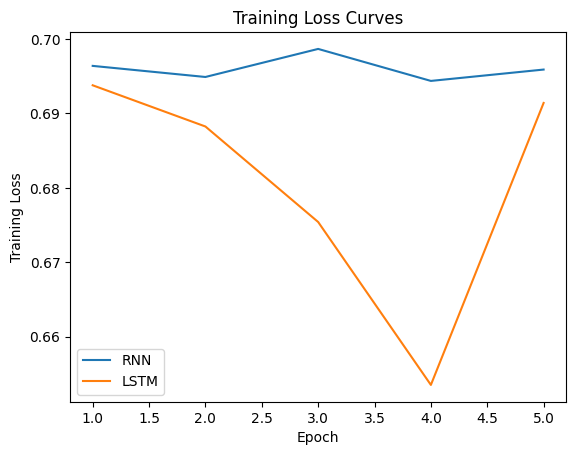

In [ ]:
print("Training Vanilla RNN...")
rnn_model = VanillaRNN(vocab_size)
rnn_losses = train_model(rnn_model, train_loader, test_loader, epochs=5)

print("\nTraining LSTM...")
lstm_model = LSTMModel(vocab_size)
lstm_losses = train_model(lstm_model, train_loader, test_loader, epochs=5)

# Plot loss curves
plt.plot(range(1,6), rnn_losses, label='RNN')
plt.plot(range(1,6), lstm_losses, label='LSTM')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Loss Curves')
plt.show()

Training function

In [ ]:
def train_model(model, train_loader, test_loader, epochs=5, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()   # combines sigmoid + binary cross entropy
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).float()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
    return train_losses

Prepare data loaders (use a subset of 10,000 samples to save time)


In [ ]:
from torch.utils.data import DataLoader, Dataset

class IMDbDataset(Dataset):
    def __init__(self, df, max_len=500):
        self.texts = df['text'].values
        self.labels = df['label'].values
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        seq = torch.tensor(text_to_seq(self.texts[idx], self.max_len))
        label = torch.tensor(self.labels[idx])
        return seq, label

# Use 10000 training samples and 5000 test samples (still >5000)
train_small = train_df.sample(10000, random_state=42)
test_small = test_df.sample(5000, random_state=42)

train_dataset = IMDbDataset(train_small)
test_dataset = IMDbDataset(test_small)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

Code for both models



In [ ]:
import torch
import torch.nn as nn

class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)   # 1 output for binary classification

    def forward(self, x):
        x = self.embedding(x)          # (batch, seq_len, embed_dim)
        _, hidden = self.rnn(x)         # hidden shape: (1, batch, hidden_dim)
        out = self.fc(hidden.squeeze(0)) # remove the 1st dimension -> (batch, 1)
        return out.squeeze(1)           # (batch,)

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)   # hidden: (1, batch, hidden_dim)
        out = self.fc(hidden.squeeze(0))
        return out.squeeze(1)

# **Define the Two Models RNN/LSTM**

In [ ]:
import re
from collections import Counter

# Simple tokenizer
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)   # remove punctuation & numbers
    return text.split()

# Build vocabulary from training set (only most frequent 20000 words)
word_counts = Counter()
for text in train_df['text']:
    word_counts.update(tokenize(text))

vocab = {word: idx+2 for idx, (word, _) in enumerate(word_counts.most_common(20000))}
vocab['<PAD>'] = 0   # padding token
vocab['<UNK>'] = 1   # unknown token
vocab_size = len(vocab)   # about 20002

# Convert text to sequence of numbers
def text_to_seq(text, max_len=500):
    tokens = tokenize(text)[:max_len]   # truncate
    seq = [vocab.get(token, 1) for token in tokens]   # 1 = <UNK>
    # pad with 0
    seq = seq + [0] * (max_len - len(seq))
    return seq

# Test on one example
print(text_to_seq("This movie was great!", max_len=10))

[11, 18, 14, 85, 0, 0, 0, 0, 0, 0]


Training samples: 25000
Test samples: 25000
Unique labels: [0 1]


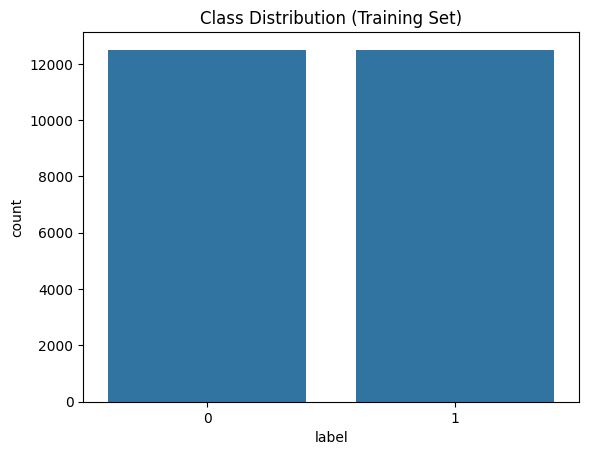

Positive example:
 Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more strik

Negative example:
 I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h
Average review length: 233.8 words
Maximum length: 2470 words


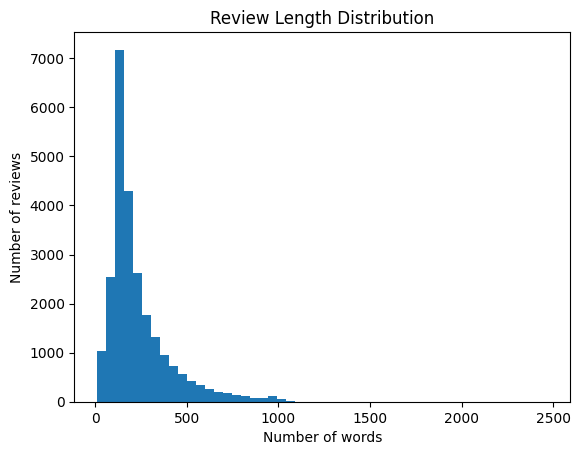

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to pandas for easy handling
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# 1. Number of samples
print(f"Training samples: {len(train_df)}")   # 25000
print(f"Test samples: {len(test_df)}")         # 25000

# 2. Number of classes
print(f"Unique labels: {train_df['label'].unique()}")  # [0, 1] -> 2 classes

# 3. Class distribution (bar chart)
sns.countplot(x='label', data=train_df)
plt.title("Class Distribution (Training Set)")
plt.show()

# 4. Example texts
print("Positive example:\n", train_df[train_df['label']==1]['text'].iloc[0][:300])
print("\nNegative example:\n", train_df[train_df['label']==0]['text'].iloc[0][:300])

# 5. Average text length (in words)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))
print(f"Average review length: {train_df['word_count'].mean():.1f} words")
print(f"Maximum length: {train_df['word_count'].max()} words")

# 6. Histogram of text lengths
plt.hist(train_df['word_count'], bins=50)
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.title("Review Length Distribution")
plt.show()

In [ ]:
from datasets import load_dataset

# Charge IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")

# Afficher un résumé
print(dataset)

# Exemple : afficher la première entrée du train
print(dataset["train"][0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and

In [ ]:
!pip install datasets matplotlib seaborn scikit-learn pandas gradio